## 0. Imports and Configurations

In [15]:
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

USE_S3 = os.getenv("USE_S3", "false").lower() == "true"

## 1. Load cleaned dataset

In [16]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, '..', 'data')

# Dynamic route to the data file
if USE_S3:
    df = pd.read_csv(f"s3://{os.getenv('S3_BUCKET')}/cleaned_data.csv")
else:
    df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)

BASE_DIR: /home/admin/Documents/nextbuy/notebooks
DATA_DIR: /home/admin/Documents/nextbuy/notebooks/../data


## User profile dataframe

In [17]:
user_profiles = df.groupby('user_id').agg(
    n_orders = ('order_id', 'nunique'),
    avg_basket_size = ('order_id', 'count'),  # a diviser pr la moyenne
    reorder_rate = ('reordered', 'mean'),
    avg_days_between_orders = ('days_since_prior_order', 'mean'),
    favorite_hour = ('order_hour_of_day', lambda x: x.mode()[0]),
    favorite_dow = ('order_dow', lambda x: x.mode()[0]),
    n_products = ('product_id', 'nunique'),
    n_aisles = ('aisle_id', 'nunique'),
    n_departments = ('department_id', 'nunique'),
)

## Users profiles classification

In [18]:
user_profiles["avg_basket_size"] = user_profiles["avg_basket_size"] / user_profiles["n_orders"]

p75_orders = user_profiles["n_orders"].quantile(0.75)
p75_basket = user_profiles["avg_basket_size"].quantile(0.75)
p75_diversity = user_profiles["n_departments"].quantile(0.75)
p75_reorder = user_profiles["reorder_rate"].quantile(0.75)

user_profiles['is_frequent'] = user_profiles['n_orders'] > p75_orders
user_profiles['is_big_basket'] = user_profiles['avg_basket_size'] > p75_basket
user_profiles['is_explorer'] = user_profiles['n_departments'] > p75_diversity
user_profiles['is_loyal'] = user_profiles['reorder_rate'] > p75_reorder

def assign_profile(row):
    if row['is_loyal'] and row['is_frequent']:
        return 'Client fidèle et fréquent'
    elif row['is_loyal']:
        return 'Routinier'
    elif row['is_big_basket']:
        return 'Gros panier'
    elif row['is_explorer']:
        return 'Explorateur'
    else:
        return 'Client occasionnel'


user_profiles['profile'] = user_profiles.apply(assign_profile, axis=1)

## Visualize the profiles

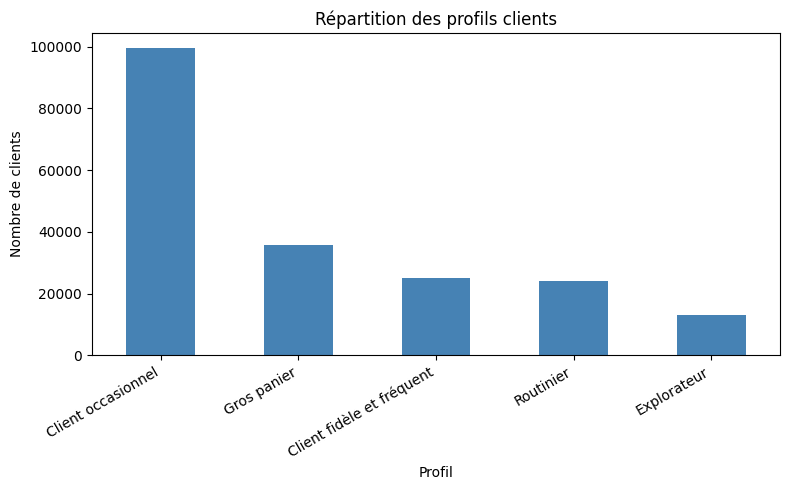

In [23]:
plt.figure(figsize=(8, 5))
user_profiles['profile'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Répartition des profils clients')
plt.xlabel('Profil')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
